# Code to make figures regarding the parameter scan
Merge all the inference files into one csv file with correlations + parameter information

In [ ]:
import pandas as pd
from pathlib import Path
parameter_df_activation = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/parameters_3genes_positive_reg_pi_on_r_add_scaled.csv", index_col=0)
parameter_df_repression = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/parameter_scan_simulations/simulation_details/parameters_3genes_repression_reg_pi_on_r_add_scaled.csv", index_col=0)
output_folder = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/"
# Path to main folder
names = ["A_to_B", "A_B", "A_rep_B", "A_and_B"]
for name in names:
    path_to_main_folder = Path(f"/home/gzu5140/Keerthana_b1042/grnInference/analysisData/parameter_scan/{name}")

    # Find all CSV files inside subfolders (recursive search)
    csv_files = list(path_to_main_folder.rglob("*.csv"))

    print(f"Found {len(csv_files)} CSV files")

    # Read and concat
    df_list = [pd.read_csv(f) for f in csv_files]
    combined_df = pd.concat(df_list, ignore_index=True)
    if "rep" in name:
        parameter_df = parameter_df_repression
    else:
        parameter_df = parameter_df_activation
    parameter_df_filtered = parameter_df[parameter_df['gene_id'] != 3]
    # Function to generate param_index directly from pair_id
    def make_param_index(pid):
        start = pid * 3
        return f"{start}_{start+1}"

    parameter_df_filtered["param_index"] = parameter_df_filtered["pair_id"].apply(make_param_index)
    def clean_param_index(val):
        parts = str(val).split("_")
        if len(parts) == 3:
            return "_".join(parts[:2])
        return val  # keep as is if already 2 parts (or unexpected format)


    combined_df['param_index'] = combined_df['param_index'].apply(clean_param_index)
    combined_df_param = pd.merge(combined_df.reset_index(drop = True), parameter_df_filtered.reset_index(drop=True), on="param_index")
    combined_df_param.to_csv(f"{output_folder}/{name}_inference_results.csv")


    


Multiple states

In [ ]:
import pandas as pd
from pathlib import Path

# === PATHS ===
base_path = Path("/home/gzu5140/Keerthana_b1042/grnInference")
param_path = base_path / "simulation_data/parameter_scan_simulations/simulation_details"
analysis_path = base_path / "analysisData/parameter_scan"
output_folder = base_path / "plot_data/parameter_scan"
output_folder.mkdir(parents=True, exist_ok=True)

# === LOAD PARAMETER TABLES ===
param_act = pd.read_csv(param_path / "parameters_3genes_positive_reg_pi_on_r_add_scaled.csv", index_col=0)
param_rep = pd.read_csv(param_path / "parameters_3genes_repression_reg_pi_on_r_add_scaled.csv", index_col=0)

# --- Keep only genes 1 & 2 ---
param_act = param_act[param_act["gene_id"] != 3].copy()
param_rep = param_rep[param_rep["gene_id"] != 3].copy()

# === HELPER: ensure param_index column ===
def ensure_param_index(df):
    if "param_index" not in df.columns and "pair_id" in df.columns:
        df["param_index"] = df["pair_id"].apply(lambda pid: f"{int(pid)*3}_{int(pid)*3+1}")
    return df

param_act = ensure_param_index(param_act)
param_rep = ensure_param_index(param_rep)

# === HELPER: split param_index into state1/state2 ===
def split_param_index(series):
    parts = series.astype(str).str.split("__", expand=True)
    parts.columns = ["param_index_state1", "param_index_state2"]
    return parts.applymap(lambda x: "_".join(str(x).split("_")[:2]) if pd.notna(x) else None)

# === PROCESS EACH DATASET ===
for name in ["A_to_B_2_states", "A_B_2_states", "A_and_B_2_states"]:
    files = list((analysis_path / name).rglob("*.csv"))
    print(f"Found {len(files)} CSVs for {name}")
    if not files:
        continue

    df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
    df = pd.concat([df, split_param_index(df["param_index"])], axis=1)

    params = param_rep if "rep" in name else param_act

    # --- Merge parameters for both states ---
    for state in ["state1", "state2"]:
        merged_cols = {c: f"{c}_{state}" for c in params.columns if c != "param_index"}
        df = df.merge(params.rename(columns=merged_cols),
                      how="left", left_on=f"param_index_{state}", right_on="param_index").drop(columns="param_index", errors="ignore")

    out_path = output_folder / f"{name}_inference_results_new.csv"
    df.to_csv(out_path, index=False)
    print(f"✅ Saved: {out_path}")

print("\nAll merges complete.")


## Figure a - AUROC for the three cases

In [17]:
import os
output_folder_plot = Path("/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/")
os.makedirs(output_folder_plot, exist_ok = True)

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import FormatStrFormatter

# # === SETTINGS ===
# names = ["A_to_B", "A_and_B", "A_rep_B", "A_B"]
# alpha = 0.01
# n_bins = 10

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# axes = axes.flatten()

# # Collect global y-range for consistent scales
# all_neglogp_max, all_neglogp_min = [], []

# # === First pass: compute global range ===
# for name in names:
#     file = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/{name}_inference_results.csv"
#     df = pd.read_csv(file)
#     if "gene_id" not in df.columns:
#         continue
#     if "k_add_gene_1_to_gene_2" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_1_to_gene_2"] = df["k_add_gene_1_to_gene_2"] / df["k_on"]
#     subset = df[df["gene_id"] == 2].copy()
#     if "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10" not in subset.columns:
#         continue
#     subset["pval_safe"] = subset["pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"].replace(0, 1e-6)
#     subset["neglogp"] = -np.log10(subset["pval_safe"])
#     all_neglogp_max.append(subset["neglogp"].max())
#     all_neglogp_min.append(subset["neglogp"].min())

# global_ymin, global_ymax = min(all_neglogp_min), max(all_neglogp_max)

# # === Helper function to align 0 baselines ===
# def align_yaxes(ax1, v1, ax2, v2):
#     """Align the value v1 on ax1 with value v2 on ax2."""
#     y1_lo, y1_hi = ax1.get_ylim()
#     y2_lo, y2_hi = ax2.get_ylim()
#     scale1 = (v1 - y1_lo) / (y1_hi - y1_lo)
#     scale2 = (v2 - y2_lo) / (y2_hi - y2_lo)
#     new_y2_lo = y2_lo + (scale1 - scale2) * (y2_hi - y2_lo)
#     ax2.set_ylim(new_y2_lo, y2_hi)

# # === MAIN LOOP ===
# for i, name in enumerate(names):
#     ax1 = axes[i]
#     ax2 = ax1.twinx()

#     file = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/{name}_inference_results.csv"
#     print(f"\n📂 Processing {name}")
#     df = pd.read_csv(file)
#     if "gene_id" not in df.columns:
#         continue

#     # Create ratios
#     if "k_add_gene_1_to_gene_2" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_1_to_gene_2"] = df["k_add_gene_1_to_gene_2"] / df["k_on"]
#     if "k_add_gene_2_to_gene_1" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_2_to_gene_1"] = df["k_add_gene_2_to_gene_1"] / df["k_on"]

#     pval_12 = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
#     pval_21 = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
#     if pval_12 not in df.columns:
#         continue

#     # === Activation vs repression bin rules ===
#     if "rep" in name.lower():
#         bin_mode = "adaptive"
#     else:
#         bin_mode = "fixed"

#     # === Compute for gene 1 → 2 ===
#     subset_12 = df[df["gene_id"] == 2].copy()
#     subset_12["pval_safe"] = subset_12[pval_12].replace(0, 1e-6)
#     subset_12["neglogp"] = -np.log10(subset_12["pval_safe"])
#     x12 = subset_12["kadd_over_kon_gene_1_to_gene_2"]
    
#     # === Compute for gene 2 → 1 (if exists) ===
#     subset_21 = df[df["gene_id"] == 1].copy()
#     if pval_21 in subset_21.columns:
#         subset_21["pval_safe"] = subset_21[pval_21].replace(0, 1e-6)
#         x21 = subset_21["kadd_over_kon_gene_2_to_gene_1"]
#     else:
#         subset_21 = None

#     # === BINNING ===
#     if bin_mode == "fixed":
#         bins_12 = np.linspace(0.5, 10.5, 11)

#     else:
#         bins_12 = np.linspace(x12.min(), x12.max(), n_bins + 1)
#     if name == "A_B":
#         x12 = np.zeros_like(x12)
#         bins_12 = np.array([-0.5, 0.5])

#     subset_12["x_bin"] = pd.cut(x12, bins_12, include_lowest=True)
#     stats_12 = subset_12.groupby("x_bin")["pval_safe"].agg(
#         n="size",
#         frac=lambda p: np.mean(p < alpha)
#     )
#     bin_centers_12 = [interval.mid for interval in stats_12.index.categories]
#     fractions_12 = stats_12["frac"].values
#     n_vals_12 = stats_12["n"].values
#     ci_12 = 1.96 * np.sqrt(fractions_12 * (1 - fractions_12) / n_vals_12)

#     groups_12 = [group["neglogp"].values for _, group in subset_12.groupby("x_bin")]

#     # --- Boxplot for gene 1→2 ---
#     box = ax1.boxplot(
#         groups_12,
#         positions=bin_centers_12,
#         widths=(bins_12[1] - bins_12[0]) * 0.7,
#         patch_artist=True,
#         showfliers=True,
#     )
#     for patch in box["boxes"]:
#         patch.set(facecolor="lightgray", edgecolor="black")

#     ax1.axhline(2, color="black", linestyle="--", linewidth=1)
#     ax1.set_ylabel(r"$-log_{10}(p)$", fontsize=12)
#     ax1.set_xlabel(r"$\frac{k_{add}^{max}}{k_{on}}$", fontsize=15)
#     ax1.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
#     ax1.grid(False)
#     ax1.set_ylim(global_ymin, global_ymax + 0.5)

#     # --- Fraction curves ---
#     ax2.plot(bin_centers_12, fractions_12, "o-", color="red", lw=2, label="gene 1 → gene 2")

#     # If bidirectional (A_and_B) → plot second line
#     if name == "A_and_B" and subset_21 is not None and not subset_21.empty:
#         if bin_mode == "fixed":
#             bins_21 = np.linspace(1, 10, n_bins + 1)
#         else:
#             bins_21 = np.linspace(x21.min(), x21.max(), n_bins + 1)
#         subset_21["x_bin"] = pd.cut(x21, bins_21, include_lowest=True)
#         stats_21 = subset_21.groupby("x_bin")["pval_safe"].agg(
#             n="size",
#             frac=lambda p: np.mean(p < alpha)
#         )
#         bin_centers_21 = [interval.mid for interval in stats_21.index.categories]
#         fractions_21 = stats_21["frac"].values
#         n_vals_21 = stats_21["n"].values
#         ci_21 = 1.96 * np.sqrt(fractions_21 * (1 - fractions_21) / n_vals_21)
#         ax2.plot(bin_centers_21, fractions_21, "s--", color="blue", lw=2, label="gene 2 → gene 1")
    

#     ax2.set_ylabel("Fraction p < 0.01", fontsize=12)
#     ax2.tick_params(axis="y", colors="black")
#     ax2.set_ylim(0, 1)
#     align_yaxes(ax1, 0, ax2, 0)

#     # --- Titles ---
#     title_map = {
#         "A_to_B": "A → B (Activation)",
#         "A_and_B": "A ↔ B (Bidirectional)",
#         "A_rep_B": "A ⊣ B (Repression)",
#         "A_B": "A–B (Independent)"
#     }
#     ax1.set_title(title_map.get(name, name), fontsize=14, pad=8)
#     if name == "A_and_B":
#         ax2.legend(frameon=False, loc="lower right", fontsize=9)

# # === Final layout ===
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.3, hspace=0.35)
# # fig.suptitle(r"Significance vs $k_{add}^{max}/k_{on}$ across networks", fontsize=16, y=1.03)
# plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import FormatStrFormatter
# from pathlib import Path

# # === SETTINGS ===
# names = ["A_to_B", "A_and_B", "A_rep_B", "A_B"]
# alpha = 0.01
# n_bins = 10

# # Color scheme (same as direction plots)
# color_forward = "#194a9e"   # blue (X→Y)
# color_reverse = "#e84b2c"   # red  (Y→X)

# # Labels
# title_map = {
#     "A_to_B": "X → Y (Activation)",
#     "A_and_B": "X ↔ Y (Bidirectional)",
#     "A_rep_B": "X ⊣ Y (Repression)",
#     "A_B": "X Y (Independent)"
# }

# # === Global y-range ===
# all_neglogp = []
# for name in names:
#     f = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/{name}_inference_results.csv"
#     df = pd.read_csv(f)
#     if "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10" not in df.columns:
#         continue
#     df["pval_safe"] = df["pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"].replace(0, 1e-6)
#     all_neglogp.extend(-np.log10(df["pval_safe"]))
# global_ymin, global_ymax = np.min(all_neglogp), np.max(all_neglogp)

# # === Figure ===
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.flatten()
# legend_handles = []

# for i, name in enumerate(names):
#     ax1 = axes[i]
#     file = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/{name}_inference_results.csv"
#     df = pd.read_csv(file)
#     if "gene_id" not in df.columns:
#         continue

#     # Ratios
#     if "k_add_gene_1_to_gene_2" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_1_to_gene_2"] = df["k_add_gene_1_to_gene_2"] / df["k_on"]
#     if "k_add_gene_2_to_gene_1" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_2_to_gene_1"] = df["k_add_gene_2_to_gene_1"] / df["k_on"]

#     pval_col = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
#     subset_12 = df[df["gene_id"] == 2].copy()
#     subset_12["pval_safe"] = subset_12[pval_col].replace(0, 1e-6)
#     subset_12["neglogp"] = -np.log10(subset_12["pval_safe"])
#     x12 = subset_12["kadd_over_kon_gene_1_to_gene_2"]

#     # --- Bin edges ---
#     if name == "A_B":
#         # Independent: force all x12 = 0, single dummy bin
#         x12 = np.zeros_like(x12)
#         bins_12 = np.array([-0.5, 0.5])
#         subset_12["x_bin"] = pd.Categorical(["center"] * len(x12))
#         bin_centers_12 = [0]
#     else:
#         if "rep" in name.lower():
#             bins_12 = np.linspace(x12.min(), x12.max(), n_bins + 1)
#         else:
#             bins_12 = np.linspace(0.5, 10.5, 11)
#         subset_12["x_bin"] = pd.cut(x12, bins_12, include_lowest=True)
#         bin_centers_12 = [interval.mid for interval in subset_12["x_bin"].cat.categories]

#     # --- Statistics ---
#     stats_12 = subset_12.groupby("x_bin")["pval_safe"].agg(frac=lambda p: np.mean(p < alpha))
#     fractions_12 = stats_12["frac"].values
#     groups_12 = [group["neglogp"].values for _, group in subset_12.groupby("x_bin")]

#     # --- Boxplot (X→Y) ---
#     ax1.boxplot(
#         groups_12,
#         positions=bin_centers_12,
#         widths=(bins_12[1] - bins_12[0]) * 0.7 if len(bins_12) > 1 else 0.5,
#         patch_artist=True,
#         boxprops=dict(facecolor="white", edgecolor="black", linewidth=1),
#         medianprops=dict(color="black", linewidth=1),
#         whiskerprops=dict(color="black", linewidth=1),
#         capprops=dict(color="black", linewidth=1),
#         flierprops=dict(marker="o", markersize=3, markerfacecolor="black", markeredgecolor="black")
#     )

#     # --- Fraction line ---
#     ax2 = ax1.twinx()
#     line_forward, = ax2.plot(bin_centers_12, fractions_12, "o-", color=color_forward, lw=2, label="X → Y")

#     # --- Add Y→X for bidirectional ---
#     if name == "A_and_B" and "kadd_over_kon_gene_2_to_gene_1" in df.columns:
#         subset_21 = df[df["gene_id"] == 1].copy()
#         subset_21["pval_safe"] = subset_21[pval_col].replace(0, 1e-6)
#         x21 = subset_21["kadd_over_kon_gene_2_to_gene_1"]
#         bins_21 = np.linspace(0.5, 10.5, 11)
#         subset_21["x_bin"] = pd.cut(x21, bins_21, include_lowest=True)
#         stats_21 = subset_21.groupby("x_bin")["pval_safe"].agg(frac=lambda p: np.mean(p < alpha))
#         bin_centers_21 = [interval.mid for interval in subset_21["x_bin"].cat.categories]
#         fractions_21 = stats_21["frac"].values
#         line_reverse, = ax2.plot(bin_centers_21, fractions_21, "s--", color=color_reverse, lw=2, label="Y → X")
#         legend_handles.extend([line_forward, line_reverse])
#     else:
#         legend_handles.append(line_forward)

#     # --- Formatting ---
#     ax1.axhline(2, color="black", linestyle="--", linewidth=1)
#     ax1.set_ylim(global_ymin, global_ymax + 1)
#     ax2.set_ylim(0, 1.05)

#     # Correct x-limits
#     if name == "A_B":
#         ax1.set_xlim(-1, 1)
#     elif "rep" in name.lower():
#         ax1.set_xlim(x12.min(), x12.max())
#     else:
#         ax1.set_xlim(0.5, 10.5)

#     ax1.set_ylabel(r"$-log_{10}(p)$", fontsize=12)
#     ax2.set_ylabel("Fraction p < 0.01", fontsize=12)
#     ax1.set_xlabel(r"$\frac{k_{add}^{max}}{k_{on}}$", fontsize=20)
#     ax1.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
#     ax1.set_title(title_map.get(name, name), fontsize=13)
#     ax1.tick_params(axis="both", labelsize=10)
#     ax2.tick_params(axis="y", labelsize=10)
#     ax1.spines["top"].set_visible(True)
#     ax2.spines["top"].set_visible(True)

# # === Deduplicated legend ===
# unique_handles, unique_labels = [], []
# for h in legend_handles:
#     lbl = h.get_label()
#     if lbl not in unique_labels:
#         unique_labels.append(lbl)
#         unique_handles.append(h)
# fig.legend(unique_handles, unique_labels, loc="lower center", ncol=2, frameon=False, fontsize=11)

# plt.tight_layout(rect=[0, 0.07, 1, 1])
# png_path = output_folder_plot / "XY_significance_vs_kadd_over_kon_fixed_limits.png"
# svg_path = output_folder_plot / "XY_significance_vs_kadd_over_kon_fixed_limits.svg"
# plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.show()

# print(f"✅ Saved:\n{png_path}\n{svg_path}")


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from pathlib import Path

# # === SETTINGS ===
# names = ["A_to_B", "A_and_B", "A_rep_B", "A_B"]

# color_forward = "#194a9e"  # blue (X→Y)
# color_reverse = "#e84b2c"  # red (Y→X)
# max_bins = 10

# title_map = {
#     "A_to_B": "X → Y (Activation)",
#     "A_and_B": "X ↔ Y (Bidirectional)",
#     "A_rep_B": "X ⊣ Y (Repression)",
#     "A_B": "X Y (Independent)"
# }


# def adaptive_bins(x, n_bins=10):
#     """Quantile-based adaptive binning with equal counts per bin."""
#     x = np.asarray(x[~np.isnan(x)])
#     if len(x) == 0:
#         return np.linspace(0, 1, 2)
#     if len(x) < n_bins:
#         n_bins = max(2, len(x) // 5)
#     q = np.linspace(0, 1, n_bins + 1)
#     edges = np.quantile(x, q)
#     edges = np.unique(edges)
#     if len(edges) < 2:
#         edges = np.linspace(x.min(), x.max(), 2)
#     edges[-1] += 1e-9  # include upper edge
#     return edges


# # === FIGURE ===
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.flatten()

# for i, name in enumerate(names):
#     ax = axes[i]
#     print(f"\n📂 Processing {name}")

#     file = f"/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan/{name}_inference_results.csv"
#     df = pd.read_csv(file)
#     if "gene_id" not in df.columns:
#         continue

#     # compute ratios
#     if "k_add_gene_1_to_gene_2" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_1_to_gene_2"] = df["k_add_gene_1_to_gene_2"] / df["k_on"]
#     if "k_add_gene_2_to_gene_1" in df.columns and "k_on" in df.columns:
#         df["kadd_over_kon_gene_2_to_gene_1"] = df["k_add_gene_2_to_gene_1"] / df["k_on"]

#     corr_col = "corr_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"

#     # --- X→Y subset ---
#     subset_12 = df[df["gene_id"] == 2].copy()
#     subset_12[corr_col] = subset_12[corr_col].replace([np.inf, -np.inf], np.nan)
#     x12 = subset_12["kadd_over_kon_gene_1_to_gene_2"]
#     y12 = subset_12[corr_col]

#     # --- Handle Independent (A_B) before binning ---
#     if name == "A_B":
#         # all zero x12 → single dummy bin
#         x12 = np.zeros_like(x12)
#         bins_12 = np.array([-0.5, 0.5])
#         subset_12["x_bin"] = pd.Categorical(["center"] * len(x12))
#         bin_centers_12 = [0]
#         grouped_12 = {"center": subset_12}
#     else:
#         # --- Normal binning ---
#         if "rep" in name.lower():
#             bins_12 = adaptive_bins(x12, n_bins=max_bins)
#         else:
#             bins_12 = np.linspace(1, 10, max_bins + 1)
#         subset_12["x_bin"] = pd.cut(x12, bins_12, include_lowest=True, right=True)
#         grouped_12 = subset_12.groupby("x_bin", observed=True)

#         bin_centers_12, groups_12, medians_12 = [], [], []
#         for cat in subset_12["x_bin"].cat.categories:
#             if cat not in grouped_12.groups:
#                 continue
#             vals = grouped_12.get_group(cat)[corr_col].dropna().values
#             if len(vals) == 0:
#                 continue
#             groups_12.append(vals)
#             bin_centers_12.append(cat.mid)
#             medians_12.append(np.nanmedian(vals))

#     # --- Special case: A_B groups ---
#     if name == "A_B":
#         groups_12 = [subset_12[corr_col].dropna().values]
#         medians_12 = [np.nanmedian(subset_12[corr_col])]

#     # --- Boxplot ---
#     box = ax.boxplot(
#         groups_12,
#         positions=bin_centers_12,
#         widths=(bin_centers_12[1] - bin_centers_12[0]) * 0.7 if len(bin_centers_12) > 1 else 0.5,
#         patch_artist=True,
#         showfliers=True,
#         boxprops=dict(linewidth=1, color="black"),
#         medianprops=dict(color="black", linewidth=1.5),
#         whiskerprops=dict(color="black", linewidth=1),
#         capprops=dict(color="black", linewidth=1),
#         flierprops=dict(marker="o", markersize=2.5, markerfacecolor="black", markeredgecolor="black"),
#     )
#     for patch in box["boxes"]:
#         patch.set(facecolor="white", edgecolor="black")

#     # --- Median line ---
#     ax.plot(
#         bin_centers_12,
#         medians_12,
#         color=color_forward,
#         lw=2.2,
#         marker="o",
#         markersize=4,
#         label="X → Y",
#     )

#     # --- Y→X for bidirectional ---
#     if name == "A_and_B":
#         subset_21 = df[df["gene_id"] == 1].copy()
#         subset_21[corr_col] = subset_21[corr_col].replace([np.inf, -np.inf], np.nan)
#         x21 = subset_21["kadd_over_kon_gene_2_to_gene_1"]
#         y21 = subset_21[corr_col]
#         subset_21["x_bin"] = pd.cut(x21, bins_12, include_lowest=True, right=True)

#         grouped_21 = subset_21.groupby("x_bin", observed=True)
#         bin_centers_21, medians_21 = [], []
#         for cat in subset_21["x_bin"].cat.categories:
#             if cat not in grouped_21.groups:
#                 continue
#             vals = grouped_21.get_group(cat)[corr_col].dropna().values
#             if len(vals) == 0:
#                 continue
#             bin_centers_21.append(cat.mid)
#             medians_21.append(np.nanmedian(vals))

#         ax.plot(
#             bin_centers_21,
#             medians_21,
#             "s--",
#             color=color_reverse,
#             lw=2,
#             markersize=4,
#             label="Y → X",
#         )
#         ax.legend(frameon=False, loc="upper right", fontsize=9)

#     # --- Axes ---
#     ax.axhline(0, color="black", linestyle="--", linewidth=1)
#     ax.set_ylabel("Correlation (X and Y)", fontsize=12)
#     ax.set_xlabel(r"$\frac{k_{add}^{max}}{k_{on}}$ ", fontsize=12)
#     ax.set_yscale("symlog", linthresh=0.005)
#     ax.set_ylim(-1, 1)

#     if name == "A_B":
#         ax.set_xlim(-1, 1)
#         ax.set_xticks([0])
#         ax.set_xticklabels(["0"], fontsize=10)
#     else:
#         ax.set_xlim(bin_centers_12[0] - 0.1, bin_centers_12[-1] + 0.1)
#         ax.set_xticks(bin_centers_12)
#         ax.set_xticklabels([f"{x:.2f}" for x in bin_centers_12], fontsize=10)

#     ax.tick_params(axis="both", which="major", labelsize=9)
#     ax.set_yticks([-0.1, -0.01, 0, 0.01, 0.1])
#     ax.set_yticklabels(["−0.1", "−0.01", "0", "0.01", "0.1"], fontsize=10)
#     ax.set_title(title_map.get(name, name), fontsize=13, pad=6)

# # === Layout & Export ===
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.3, hspace=0.35)

# png_path = output_folder_plot / "XY_correlation_vs_kadd_over_kon.png"
# svg_path = output_folder_plot / "XY_correlation_vs_kadd_over_kon.svg"
# plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.show()

# print(f"\n✅ Saved:\n{png_path}\n{svg_path}")


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.ticker import LogFormatterMathtext
# from matplotlib.lines import Line2D
# from pathlib import Path

# # === SETTINGS ===
# folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan")
# pval_col = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
# p_vals = np.logspace(-4, 0, 60)
# alpha_line = 0.01

# # --- Fixed scenario colors ---
# fixed_colors = {
#     "A_B": "#bc0f58",             # independent (false positives)
#     "A_to_B": "#6b4b2e",          # activation
#     "A_to_B_2_states": "#006937", # activation (multi-state)
#     "A_B_2_states": "#ee9127"     # independent (multi-state)
# }

# # --- Display names ---
# name_map = {
#     "A_B": "X Y",
#     "A_B_2_states": "X Y (multi-state)",
#     "A_to_B": "X → Y",
#     "A_to_B_2_states": "X → Y (multi-state)",
#     "A_and_B": "X ↔ Y",
#     "A_and_B_2_states": "X ↔ Y (multi-state)",
#     "A_rep_B": "X ⊣ Y",
#     "A_rep_B_2_states": "X ⊣ Y (multi-state)"
# }

# # --- Output folder ---

# # --- Figure style ---
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size": 11,
#     "axes.linewidth": 1,
#     "xtick.major.width": 1,
#     "ytick.major.width": 1,
# })

# fig, ax = plt.subplots(figsize=(8, 6))
# summary = []
# fallback_colors = plt.cm.Set2.colors
# extra_color_idx = 0

# # --- Label true vs false cases ---
# true_positive_cases = {"A_to_B", "A_to_B_2_states", "A_and_B", "A_and_B_2_states", "A_rep_B", "A_rep_B_2_states"}
# false_positive_cases = {"A_B", "A_B_2_states"}

# # === MAIN LOOP ===
# for csv_file in sorted(folder.glob("*_inference_results.csv")):
#     name = csv_file.stem.replace("_inference_results", "")
#     display_name = name_map.get(name, name)
#     df = pd.read_csv(csv_file)

#     if pval_col not in df.columns:
#         continue

#     # Identify unique pair key
#     if "param_index_state1" in df.columns and "param_index_state2" in df.columns:
#         df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
#     elif "param_index" in df.columns:
#         df["_pair_key"] = df["param_index"].astype(str)
#     else:
#         raise KeyError("No param_index or param_index_state1/state2 found")

#     # Compute min p-value per pair
#     pair_min_p = df.groupby("_pair_key")[pval_col].min()
#     frac_sig = [(pair_min_p < p).mean() for p in p_vals]

#     # Choose color
#     color = fixed_colors.get(name, fallback_colors[extra_color_idx % len(fallback_colors)])
#     if name not in fixed_colors:
#         extra_color_idx += 1

#     # Line style: dashed for false positives (independent); solid otherwise
#     linestyle = "--" if name in false_positive_cases else "-"

#     ax.plot(
#         p_vals,
#         frac_sig,
#         lw=2.2,
#         color=color,
#         linestyle=linestyle,
#         marker="o",
#         markersize=4,
#         markevery=6,
#         alpha=0.95,
#         label=display_name,
#     )

#     summary.append((name, len(pair_min_p), (pair_min_p < alpha_line).sum()))

# # === AXES ===
# ax.set_xscale("log")
# ax.set_xlabel("p-value threshold", fontsize=13)
# ax.set_ylabel("Fraction of significant gene–gene correlations", fontsize=13)
# ax.xaxis.set_major_formatter(LogFormatterMathtext())

# # Reference line
# ax.axvline(alpha_line, linestyle="--", color="gray", lw=1.2)
# ax.text(alpha_line * 1.1, 0.05, "p = 0.01", rotation=90,
#         va="bottom", ha="left", color="gray", fontsize=10)

# # === LEGENDS (preserve both) ===
# # Main legend (scenarios/colors)
# handles, labels = ax.get_legend_handles_labels()
# main_legend = ax.legend(handles, labels, frameon=False, loc="center left",
#                         fontsize=11, handlelength=3, labelspacing=0.6)

# # Separate legend explaining line styles
# style_lines = [
#     Line2D([0], [0], color="black", lw=2, linestyle="-", label="True positives"),
#     Line2D([0], [0], color="black", lw=2, linestyle="--", label="False positives"),
# ]
# style_legend = ax.legend(handles=style_lines, loc="upper left", frameon=False, fontsize=10)

# # Re-add the first legend so both show
# ax.add_artist(main_legend)

# # === FINISHING TOUCHES ===
# ax.tick_params(axis="both", which="major", labelsize=11)
# ax.set_xlim(1e-4, 1.05)
# ax.set_ylim(0, 1.05)
# plt.tight_layout()

# # === SAVE ===
# png_path = output_folder_plot / "XY_fraction_significant_vs_pvalue_threshold_TP_FP_doublelegend.png"
# svg_path = output_folder_plot / "XY_fraction_significant_vs_pvalue_threshold_TP_FP_doublelegend.svg"
# plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
# plt.show()

# print(f"\n✅ Saved:\n{png_path}\n{svg_path}")

# # --- Summary ---
# print("\n=== Summary (p < 0.01) ===")
# for n, tot, sig in summary:
#     print(f"{n:20s} → total: {tot:6d}, significant: {sig:6d}, fraction: {sig/tot:.3f}")


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from pathlib import Path

# # === SETTINGS ===
# pval_col   = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
# zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"

# p_vals       = np.logspace(-4, 0, 60)       # for single-state vs XY
# z_thresholds = np.arange(0, 51, 1)          # for multi-state vs single-state
# p_fixed      = 0.01                         # fixed p-value cutoff for multi-state mode

# # === COLORS & NAMES ===
# fixed_colors = {
#     "A_B": "#bc0f58", "A_B_2_states": "#ee9127",
#     "A_to_B": "#6b4b2e", "A_to_B_2_states": "#006937",
#     "A_and_B": "#084594", "A_and_B_2_states": "#4292c6",
#     "A_rep_B": "#800026", "A_rep_B_2_states": "#fc4e2a"
# }
# name_map = {
#     "A_B": "X Y", "A_B_2_states": "X Y (multi-state)",
#     "A_to_B": "X → Y", "A_to_B_2_states": "X → Y (multi-state)",
#     "A_and_B": "X ↔ Y", "A_and_B_2_states": "X ↔ Y (multi-state)",
#     "A_rep_B": "X ⊣ Y", "A_rep_B_2_states": "X ⊣ Y (multi-state)"
# }

# # === COMPARISON PAIRS ===
# comparison_pairs = {
#     # single-state vs no regulation
#     "A_to_B": "A_B",
#     "A_and_B": "A_B",
#     "A_rep_B": "A_B",
#     # multi-state vs single-state
#     "A_to_B_2_states": "A_to_B",
#     "A_and_B_2_states": "A_and_B",
#     "A_rep_B_2_states": "A_rep_B"
# }

# # === ROC helper ===
# def compute_roc(tp_frac, fp_frac):
#     fpr = np.clip(fp_frac, 0, 1)
#     tpr = np.clip(tp_frac, 0, 1)
#     order = np.argsort(fpr)
#     fpr, tpr = fpr[order], tpr[order]
#     if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
#     if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
#     auroc = np.trapz(tpr, fpr)
#     return fpr, tpr, auroc


# # === LOAD FILES ===
# dfs = {}
# for csv_file in sorted(folder.glob("*_inference_results.csv")):
#     name = csv_file.stem.replace("_inference_results", "")
#     df = pd.read_csv(csv_file)
#     if pval_col in df.columns and zscore_col in df.columns:
#         dfs[name] = df

# # === COMPUTE FRACTIONS ===
# frac_curves_p = {}
# frac_curves_z = {}

# for name, df in dfs.items():
#     # --- Build unique pair key
#     if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
#         df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
#     elif "param_index" in df.columns:
#         df["_pair_key"] = df["param_index"].astype(str)
#     else:
#         continue

#     # --- For p-value mode (single-state vs XY)
#     pair_min_p = df.groupby("_pair_key")[pval_col].min()
#     frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])

#     # --- For z-score mode (multi-state vs single-state)
#     df_sig = df[df[pval_col] < p_fixed]
#     if df_sig.empty:
#         continue
#     pair_max_z = df_sig.groupby("_pair_key")[zscore_col].max().abs()
#     frac_curves_z[name] = np.array([(pair_max_z > z).mean() for z in z_thresholds])


# # === GENERATE ROC PLOTS ===
# print("=== Generating AUROC curves ===")

# for tp_name, fp_name in comparison_pairs.items():
#     # determine mode
#     if "_2_states" in tp_name:
#         mode = "zscore"
#         frac_dict = frac_curves_z
#         thresholds = z_thresholds
#         x_lab = "|Z| threshold (multi-state identification)"
#         title_tag = "Multi-state identification (p < 0.01)"
#     else:
#         mode = "pval"
#         frac_dict = frac_curves_p
#         thresholds = p_vals
#         x_lab = "p-value threshold"
#         title_tag = "Regulation detection"

#     if tp_name not in frac_dict or fp_name not in frac_dict:
#         print(f"⚠️ Missing {tp_name} or {fp_name}")
#         continue

#     tp_frac = frac_dict[tp_name]
#     fp_frac = frac_dict[fp_name]
#     fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)

#     color = fixed_colors.get(tp_name, "tab:blue")
#     display_name = name_map.get(tp_name, tp_name)
#     base_name = name_map.get(fp_name, fp_name)

#     plt.figure(figsize=(5.5, 4.5))
#     plt.plot(fpr, tpr, "o-", color=color, label=display_name, alpha=0.9)
#     plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2, label="Random baseline")
#     plt.title(f"{display_name} vs {base_name}\n{title_tag}", fontsize=13)
#     plt.xlabel("False Positive Rate", fontsize=12)
#     plt.ylabel("True Positive Rate", fontsize=12)
#     plt.xlim(0, 1)
#     plt.ylim(0, 1.05)
#     plt.grid(alpha=0.3)
#     plt.text(0.05, 0.85, f"AUROC = {auroc:.3f}", color=color,
#              fontsize=12, transform=plt.gca().transAxes)
#     plt.legend(frameon=False, fontsize=10, loc="lower right")
#     plt.tight_layout()

#     save_path = output_folder_plot / f"ROCcurve_{tp_name}_vs_{fp_name}_{mode}.png"
#     plt.savefig(save_path, dpi=500, bbox_inches="tight", transparent=False)
#     plt.show()

#     print(f"✅ Saved: {save_path} (AUROC={auroc:.3f})")

# print("\nAll ROC curves generated successfully.")


In [32]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": "X → Y",
    "A_to_B_2_states": "X → Y (multi-state)",
    "A_and_B": "X ↔ Y",
    "A_and_B_2_states": "X ↔ Y (multi-state)",
    "A_rep_B": "X ⊣ Y",
    "A_rep_B_2_states": "X ⊣ Y (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results.csv")):
    name = csv_file.stem.replace("_inference_results", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)
    pair_min_p = df.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])

    # --- For z-score mode (multi-state vs single-state)
    df_sig = df[df[pval_col] < p_fixed]
    
    if df_sig.empty:
        continue
    pair_max_z = df_sig.groupby("_pair_key")[zscore_col].max().abs()
    frac_curves_z[name] = np.array([(pair_max_z > z).mean() for z in z_thresholds])
    
results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B", "A_B_2_states", "A_to_B_2_states", "A_and_B_2_states", "A_rep_B_2_states"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")

# === Generate ROC: PART 2 – Multi-state only (2_states vs corresponding single)
results_multi_only = []
for tp_name, fp_name in {
    "A_B_2_states": "A_to_B",
    "A_to_B_2_states": "A_to_B",
    "A_and_B_2_states": "A_and_B",
    "A_rep_B_2_states": "A_rep_B"
}.items():
    if tp_name not in frac_curves_z or fp_name not in frac_curves_z:
        print(f"⚠️ Missing {tp_name} or {fp_name} for multi-state ROC")
        continue
    tp_frac = frac_curves_z[tp_name]
    fp_frac = frac_curves_z[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_multi_only.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Multi-state] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")


[Regulation] A_to_B vs A_B: AUROC = 0.659
[Regulation] A_and_B vs A_B: AUROC = 0.720
[Regulation] A_rep_B vs A_B: AUROC = 0.653
[Regulation] A_B_2_states vs A_B: AUROC = 0.933
[Regulation] A_to_B_2_states vs A_B: AUROC = 0.953
[Regulation] A_and_B_2_states vs A_B: AUROC = 0.954
⚠️ Missing A_rep_B_2_states or A_B for regulation ROC
[Multi-state] A_B_2_states vs A_to_B: AUROC = 0.786
[Multi-state] A_to_B_2_states vs A_to_B: AUROC = 0.816
[Multi-state] A_and_B_2_states vs A_and_B: AUROC = 0.859
⚠️ Missing A_rep_B_2_states or A_rep_B for multi-state ROC


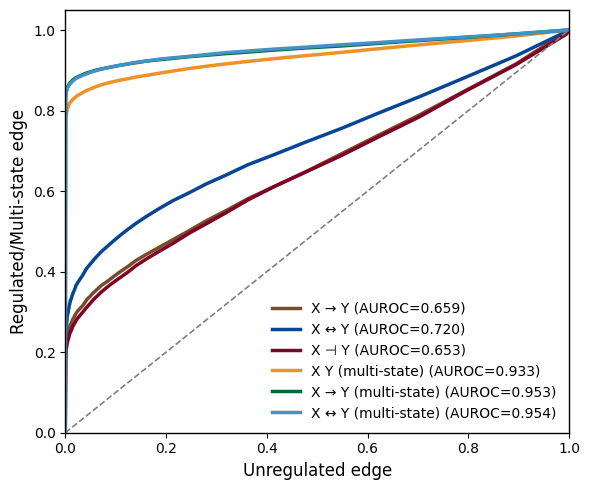

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_all_vs_XY.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_all_vs_XY.png


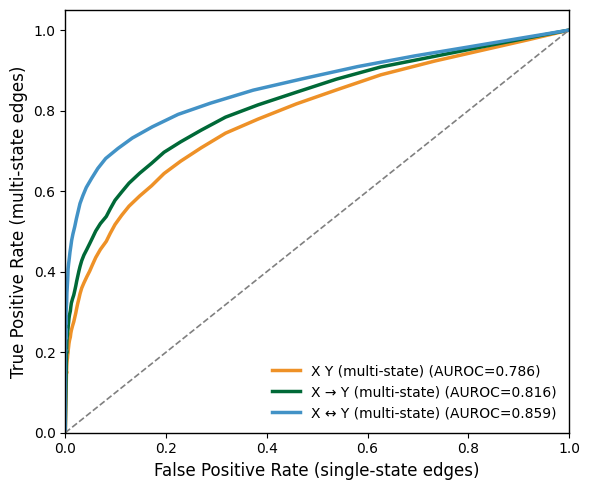

✅ Saved ROC (2-state only): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_only.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_multi_only.png


In [33]:
# === PLOTTING SETTINGS ===
plt.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "savefig.transparent": False,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.facecolor": "white",
    "axes.linewidth": 1.0,
    "axes.grid": False
})

# === Plot 1: All vs A_B (Single + Multi-state for regulation detection)
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated/Multi-state edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_all_vs_XY.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_all_vs_XY.png"
plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

# === Plot 2: Only multi-state (2_states vs corresponding single)
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_multi_only:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("False Positive Rate (single-state edges)", fontsize=12)
plt.ylabel("True Positive Rate (multi-state edges)", fontsize=12)
# plt.title("Multi-state identification", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_multi_svg = output_folder_plot / "ROCcurve_multi_only.svg"
save_multi_png = output_folder_plot / "ROCcurve_multi_only.png"
plt.savefig(save_multi_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_multi_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (2-state only): {save_multi_svg}, {save_multi_png}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.lines import Line2D
from pathlib import Path

# === SETTINGS ===
folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan")

pval_global = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"
pval_A_to_B = "directed_pval_gene_1_mRNA_t1__gene_2_mRNA_t10"
pval_B_to_A = "directed_pval_gene_2_mRNA_t1__gene_1_mRNA_t10"

p_threshold_global = 0.01
z_threshold = 10
p_vals = np.logspace(-5, 0, 60)
p_line = 0.01

# --- Label map ---
name_map = {
    "A_to_B": "X → Y",
    "A_and_B": "X ↔ Y",
    "A_rep_B": "X ⊣ Y",
    "A_B": "X Y"
}

# === Color scheme ===
color_forward = "#194a9e"   # Blue  (X→Y)
color_reverse = "#e84b2c"   # Red   (Y→X)

# === Collect only single-state ===
files = sorted([f for f in folder.glob("*_inference_results.csv") if "2_states" not in f.stem])

# === Layout ===
ncols = 2
nrows = int(np.ceil(len(files) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.8 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.linewidth": 1,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
})

label_added = False  # only show “p = 0.01” once

for ax, csv_file in zip(axes, files):
    name = csv_file.stem.replace("_inference_results", "")
    label_name = name_map.get(name, name)

    df = pd.read_csv(csv_file)
    required = [pval_global, zscore_col, pval_A_to_B, pval_B_to_A]
    if not all(c in df.columns for c in required):
        ax.set_visible(False)
        continue

    # --- Filter by significance and |Z| ---
    df_filt = df[(df[pval_global] < p_threshold_global) & (abs(df[zscore_col]) < z_threshold)]
    if df_filt.empty:
        ax.set_visible(False)
        continue

    # --- Compute cumulative fractions ---
    tp = [(df_filt[pval_A_to_B] < p).mean() for p in p_vals]
    fp = [(df_filt[pval_B_to_A] < p).mean() for p in p_vals]

    # --- Line style rules ---
    if name == "A_B":
        ls_forward, ls_reverse = "--", "--"        # both false
    elif name == "A_and_B":
        ls_forward, ls_reverse = "-", "-"          # both true
    else:
        ls_forward, ls_reverse = "-", "--"         # forward true, reverse false

    # --- Plot curves ---
    ax.plot(p_vals, tp, color=color_forward, lw=2.2, linestyle=ls_forward)
    ax.plot(p_vals, fp, color=color_reverse, lw=2.2, linestyle=ls_reverse)

    # --- Reference line ---
    ax.axvline(p_line, color="gray", linestyle="--", lw=1.2)
    if not label_added:
        ax.text(p_line * 1.1, 0.08, "p = 0.01", rotation=90,
                va="bottom", ha="left", color="gray", fontsize=10)
        label_added = True

    # --- Axes style ---
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlim(1e-5, 1)
    ax.set_ylim(0, 1.05)
    ax.set_title(label_name, fontsize=13)
    ax.tick_params(axis="both", which="major", labelsize=11)

# Hide unused panels
for ax in axes[len(files):]:
    ax.set_visible(False)

# === Shared labels ===
fig.text(-0, 0.5, "Fraction of significant edges", va="center",
         rotation="vertical", fontsize=13)
fig.text(0.5, 0.06, "p-value threshold", ha="center", fontsize=13)

# === COMBINED LEGEND ===
# Color legend (direction)
color_handles = [
    Line2D([0], [0], color=color_forward, lw=2.2, linestyle="-", label="X → Y"),
    Line2D([0], [0], color=color_reverse, lw=2.2, linestyle="-", label="Y → X")
]

# Style legend (truth)
style_handles = [
    Line2D([0], [0], color="black", lw=2.2, linestyle="-", label="True positives"),
    Line2D([0], [0], color="black", lw=2.2, linestyle="--", label="False positives")
]

# Combine both into one legend block
handles = color_handles + style_handles
labels = [h.get_label() for h in handles]

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11,
    handlelength=3,
    handletextpad=1.8,
    columnspacing=2.2,
    borderaxespad=1.2,
    labelspacing=0.8,
    bbox_to_anchor=(0.5, -0.08)   # ⬅️ move legend *below* the axis label
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])

# === SAVE ===
output_folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan")
output_folder.mkdir(parents=True, exist_ok=True)
png_path = output_folder / "XY_directional_detection_single_state_red_blue.png"
svg_path = output_folder / "XY_directional_detection_single_state_red_blue.svg"
plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
plt.show()

print(f"\n✅ Saved:\n{png_path}\n{svg_path}")


/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


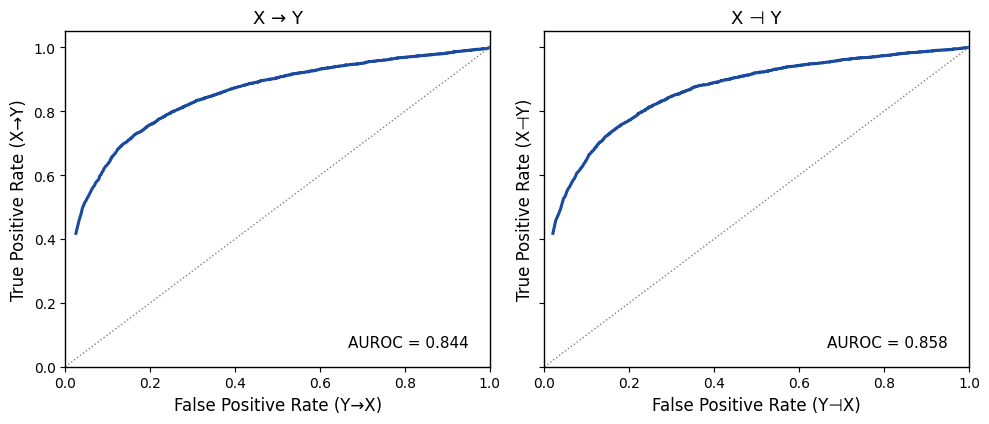


✅ Saved TPR–FPR curves:
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/TPR_vs_FPR_forward_reverse.png
/home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/TPR_vs_FPR_forward_reverse.svg


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc
from pathlib import Path

# === SETTINGS ===
folder = Path("/home/gzu5140/Keerthana_b1042/grnInference/plot_data/parameter_scan")

pval_global = "pval_gene_gene_gene_1_mRNA_gene_2_mRNA_t1_t10"
zscore_col = "zscore_twin_vs_random_gene_1_mRNA_gene_2_mRNA_t1"
pval_A_to_B = "directed_pval_gene_1_mRNA_t1__gene_2_mRNA_t10"
pval_B_to_A = "directed_pval_gene_2_mRNA_t1__gene_1_mRNA_t10"

p_threshold_global = 0.01
z_threshold = 10

name_map = {
    "A_to_B": "X → Y",
    "A_rep_B": "X ⊣ Y"
}

color_forward = "#194a9e"
color_reverse = "#e84b2c"

files = [f for f in folder.glob("*_inference_results.csv")
         if any(k in f.stem for k in ["A_to_B", "A_rep_B"]) and ("2_states" not in f.stem)]

fig, axes = plt.subplots(1, len(files), figsize=(10, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, csv_file in zip(axes, files):
    name = csv_file.stem.replace("_inference_results", "")
    label_name = name_map.get(name, name)

    df = pd.read_csv(csv_file)
    required = [pval_global, zscore_col, pval_A_to_B, pval_B_to_A]
    if not all(c in df.columns for c in required):
        ax.set_visible(False)
        continue

    # Filter
    df_filt = df[(df[pval_global] < p_threshold_global) & (abs(df[zscore_col]) < z_threshold)]
    if df_filt.empty:
        ax.set_visible(False)
        continue

    # Convert p-values to scores (−log10 p)
    eps = 1e-12
    score_fwd = -np.log10(df_filt[pval_A_to_B].clip(lower=eps))
    score_rev = -np.log10(df_filt[pval_B_to_A].clip(lower=eps))

    # Define labels: forward = True (1), reverse = False (0)
    y_true = np.ones(len(df_filt))

    # Compute ROC-like TPR for forward vs. FPR for reverse
    fpr_fwd, tpr_fwd, _ = roc_curve(y_true, score_fwd)  # both TPR=1 (since all true)
    fpr_rev, tpr_rev, _ = roc_curve(1 - y_true, score_rev)  # both FPR=0 (since all false)

    # Instead, derive matching thresholds
    thresholds = np.sort(np.unique(np.concatenate((score_fwd, score_rev))))
    tpr = [(score_fwd >= t).mean() for t in thresholds]
    fpr = [(score_rev >= t).mean() for t in thresholds]

    # Plot TPR_forward vs FPR_reverse
    ax.plot(fpr, tpr, color=color_forward, lw=2.2)
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
    auroc = auc(fpr, tpr)
    ax.text(
        0.95, 0.05, f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, color="black"
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_title(label_name, fontsize=13)
    # Custom axis labels
    if "A_to_B" in name:
        x_label = "False Positive Rate (Y→X)"
        y_label = "True Positive Rate (X→Y)"
    elif "A_rep_B" in name:
        x_label = "False Positive Rate (Y⊣X)"
        y_label = "True Positive Rate (X⊣Y)"
    else:
        x_label = "False Positive Rate"
        y_label = "True Positive Rate"

    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)


# Legend
# handles = [
#     Line2D([0], [0], color=color_forward, lw=2.2, label="TPR vs FPR"),
# ]
# fig.legend(handles, [h.get_label() for h in handles],
#            loc="lower center", ncol=1, frameon=False, fontsize=11,
#            handlelength=3, handletextpad=1.8, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# Save
png_path = output_folder_plot / "TPR_vs_FPR_forward_reverse.png"
svg_path = output_folder_plot / "TPR_vs_FPR_forward_reverse.svg"
plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=False)
plt.savefig(svg_path, dpi=600, bbox_inches="tight", transparent=False)
plt.show()

print(f"\n✅ Saved TPR–FPR curves:\n{png_path}\n{svg_path}")


## Filter the df based on certain parameters and then plot AUROC

[Regulation] A_to_B vs A_B: AUROC = 0.724
[Regulation] A_and_B vs A_B: AUROC = 0.751
[Regulation] A_rep_B vs A_B: AUROC = 0.685


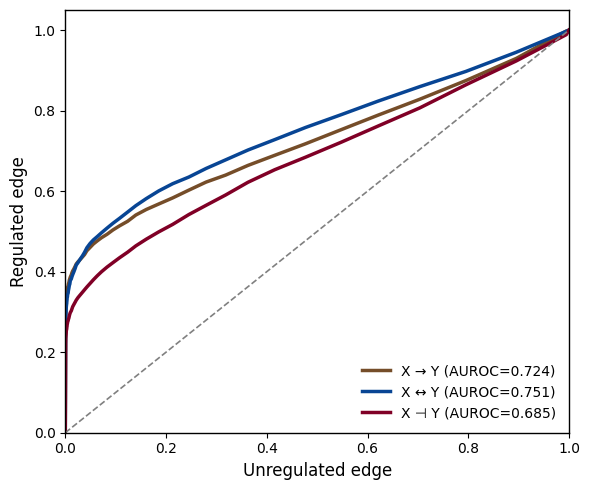

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_4.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_4.png


In [29]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": "X → Y",
    "A_to_B_2_states": "X → Y (multi-state)",
    "A_and_B": "X ↔ Y",
    "A_and_B_2_states": "X ↔ Y (multi-state)",
    "A_rep_B": "X ⊣ Y",
    "A_rep_B_2_states": "X ⊣ Y (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results.csv")):
    name = csv_file.stem.replace("_inference_results", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns and "2_states" not in name:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)

    # --- For z-score mode (multi-state vs single-state)
    if name != "A_B" and "rep" in name:
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 0.8) & (df['gene_id'] == 2)]
    elif name != "A_B":
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 4) & (df['gene_id'] == 2)]
    else:
        df_sig = df[(df['gene_id'] == 2)]
    pair_min_p = df_sig.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])
    if df_sig.empty:
        continue

results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")
    
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_4.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_4.png"
plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")

[Regulation] A_to_B vs A_B: AUROC = 0.749
[Regulation] A_and_B vs A_B: AUROC = 0.758
[Regulation] A_rep_B vs A_B: AUROC = 0.740


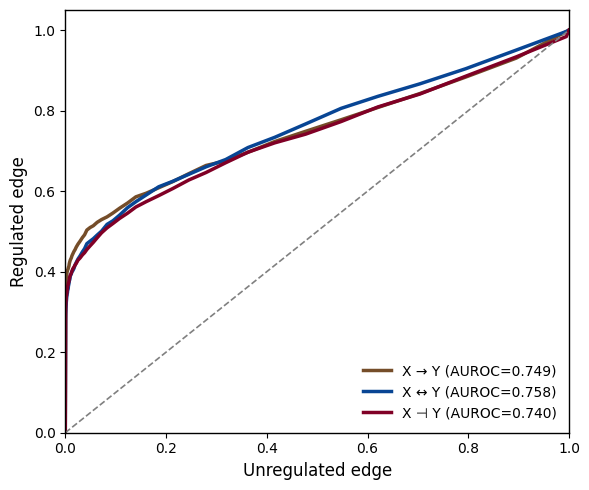

✅ Saved ROC (all vs A_B): /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_8.svg, /home/gzu5140/Keerthana_b1042/grnInference/plots/supp_figures/parameter_scan/ROCcurve_regulation_vs_XY_k_add_0_8.png


In [30]:
# === ROC helper ===
def compute_roc(tp_frac, fp_frac):
    fpr = np.clip(fp_frac, 0, 1)
    tpr = np.clip(tp_frac, 0, 1)
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    if fpr[0] > 0: fpr = np.r_[0, fpr]; tpr = np.r_[0, tpr]
    if fpr[-1] < 1: fpr = np.r_[fpr, 1]; tpr = np.r_[tpr, 1]
    auroc = np.trapz(tpr, fpr)
    return fpr, tpr, auroc

name_map = {
    "A_B": "X Y",
    "A_B_2_states": "X Y (multi-state)",
    "A_to_B": "X → Y",
    "A_to_B_2_states": "X → Y (multi-state)",
    "A_and_B": "X ↔ Y",
    "A_and_B_2_states": "X ↔ Y (multi-state)",
    "A_rep_B": "X ⊣ Y",
    "A_rep_B_2_states": "X ⊣ Y (multi-state)"
}
# === Generate ROC: PART 1 – Regulation detection (All vs A_B)
dfs = {}
for csv_file in sorted(folder.glob("*_inference_results.csv")):
    name = csv_file.stem.replace("_inference_results", "")
    df = pd.read_csv(csv_file)
    if pval_col in df.columns and zscore_col in df.columns and "2_states" not in name:
        dfs[name] = df

# === COMPUTE FRACTIONS ===
frac_curves_p = {}
frac_curves_z = {}

for name, df in dfs.items():
    if {"param_index_state1", "param_index_state2"}.issubset(df.columns):
        df["_pair_key"] = df["param_index_state1"].astype(str) + "__" + df["param_index_state2"].astype(str)
    elif "param_index" in df.columns:
        df["_pair_key"] = df["param_index"].astype(str)
    else:
        continue

    # --- For p-value mode (single-state vs XY)

    # --- For z-score mode (multi-state vs single-state)
    if name != "A_B" and "rep" in name:
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 1.6) & (df['gene_id'] == 2)]
    elif name != "A_B":
        df_sig = df[(df["k_add_gene_1_to_gene_2"]/df['k_on'] > 8) & (df['gene_id'] == 2)]
    else:
        df_sig = df[(df['gene_id'] == 2)]
    pair_min_p = df_sig.groupby("_pair_key")[pval_col].min()
    frac_curves_p[name] = np.array([(pair_min_p < p).mean() for p in p_vals])
    if df_sig.empty:
        continue

results_all_vs_A_B = []
for tp_name in ["A_to_B", "A_and_B", "A_rep_B"]:
    fp_name = "A_B"
    if tp_name not in frac_curves_p or fp_name not in frac_curves_p:
        print(f"⚠️ Missing {tp_name} or {fp_name} for regulation ROC")
        continue
    tp_frac = frac_curves_p[tp_name]
    fp_frac = frac_curves_p[fp_name]
    fpr, tpr, auroc = compute_roc(tp_frac, fp_frac)
    results_all_vs_A_B.append((tp_name, fp_name, fpr, tpr, auroc))
    print(f"[Regulation] {tp_name} vs {fp_name}: AUROC = {auroc:.3f}")
    
plt.figure(figsize=(6, 5))
for tp_name, fp_name, fpr, tpr, auroc in results_all_vs_A_B:
    label = f"{name_map.get(tp_name)} (AUROC={auroc:.3f})"
    plt.plot(fpr, tpr, "-", color=fixed_colors.get(tp_name, "black"), lw=2.5, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1.2)
plt.xlabel("Unregulated edge", fontsize=12)
plt.ylabel("Regulated edge", fontsize=12)
# plt.title("Regulation detection", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()

save_all_svg = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_8.svg"
save_all_png = output_folder_plot / "ROCcurve_regulation_vs_XY_k_add_0_8.png"
plt.savefig(save_all_svg, dpi=600, bbox_inches="tight")
plt.savefig(save_all_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ Saved ROC (all vs A_B): {save_all_svg}, {save_all_png}")